Code to replicate cross-border climate risk analysis, with EORA26 as MRIOT and ND-GAIN as climate risk index.

# MRIOT
----

## ICIO

In [8]:
import pymrio
oecd_storage = "MRIOT/ICIO/ICIO2021_2018.zip"
oecd_file = pymrio.parse_oecd(path=oecd_storage)

oecd_file.rename_sectors(    {"01T02":	"Agriculture, hunting, forestry",
"03":	"Fishing and aquaculture",
"05T06":	"Mining and quarrying, energy producing products",
"07T08":	"Mining and quarrying, non-energy producing products",
"09":	"Mining support service activities",
"10T12":	"Food products, beverages and tobacco",
"13T15":	"Textiles, textile products, leather and footwear",
"16":	"Wood and products of wood and cork",
"17T18":	"Paper products and printing",
"19":	"Coke and refined petroleum products",
"20":	"Chemical and chemical products",
"21":	"Pharmaceuticals, medicinal chemical and botanical products",
"22":	"Rubber and plastics products",
"23":	"Other non-metallic mineral products",
"24":	"Basic metals",
"25":	"Fabricated metal products",
"26":	"Computer, electronic and optical equipment",
"27":	"Electrical equipment",
"28":	"Machinery and equipment, nec ",
"29":	"Motor vehicles, trailers and semi-trailers",
"30":	"Other transport equipment",
"31T33":	"Manufacturing nec; repair and installation of machinery and equipment",
"35":	"Electricity, gas, steam and air conditioning supply",
"36T39":	"Water supply; sewerage, waste management and remediation activities",
"41T43":	"Construction",
"45T47":	"Wholesale and retail trade; repair of motor vehicles",
"49":	"Land transport and transport via pipelines",
"50":	"Water transport",
"51":	"Air transport",
"52":	"Warehousing and support activities for transportation",
"53":	"Postal and courier activities",
"55T56":	"Accommodation and food service activities",
"58T60":	"Publishing, audiovisual and broadcasting activities",
"61":	"Telecommunications",
"62T63":	"IT and other information services",
"64T66":	"Financial and insurance activities",
"68":	"Real estate activities",
"69T75":	"Professional, scientific and technical activities",
"77T82":	"Administrative and support services",
"84":	"Public administration and defence; compulsory social security",
"85":	"Education",
"86T88":	"Human health and social work activities",
"90T93":	"Arts, entertainment and recreation",
"94T96":	"Other service activities",
"97T98":	"Activities of households as employers; undifferentiated goods- and services-producing activities of households for own use"
})

oecd_file.calc_all()
mriot = oecd_file

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1671: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  Z.loc[co_name, :] + Z.loc[agg_list, :].groupby(level="sector", axis=0).sum()
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1675: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  Y.loc[co_name, :] + Y.loc[agg_list, :].groupby(level="sector", axis=0).sum()
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1681: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  Z.loc[:, co_name] + Z.loc[:, agg_list].groupby(level="sector", axis=1).sum()
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1687: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` witho

# Climate risk index
-----

## ND-GAIN

The latest version of ND-Gain (as 13/03/2024) is up to 2021, but is estimated based on future climate change projection.

Initially, there are 185 countries in ND-Gain and 66+1 in ICIO.

In [16]:
import pandas as pd
import numpy as np

# Importing ND-Gain 
########

file_path = 'ND_GAIN/resources/gain/gain.csv'
local_climate_risk = pd.read_csv(file_path)
# Selecting only the required columns and renaming them
local_climate_risk = local_climate_risk[['ISO3', '2021']]
local_climate_risk.columns = ['Country', 'Local Climate Risk']
local_climate_risk = local_climate_risk.dropna(subset=['Local Climate Risk']).reset_index(drop=True)
local_climate_risk = local_climate_risk.sort_values(by='Local Climate Risk', ascending=False)


# Find the row with the 'SDN' code
sdn_row = local_climate_risk[local_climate_risk['Country'] == 'SDN']

# Create new rows for 'SDS' and 'SUD' with the same data as 'SDN'
sds_row = sdn_row.copy()
sds_row['Country'] = 'SDS'
sud_row = sdn_row.copy()
sud_row['Country'] = 'SUD'

# Concatenate new rows to the DataFrame
local_climate_risk = pd.concat([local_climate_risk, sds_row, sud_row], ignore_index=True)

# Remove the original 'SDN' row
local_climate_risk = local_climate_risk[local_climate_risk['Country'] != 'SDN']

csv_file = "Other_data/country_codes.csv"
iso_convert = pd.read_csv(csv_file, delimiter=',')  # Assuming tab-delimited data
iso_convert.loc[iso_convert['name'] == 'Namibia', 'alpha-2'] = 'NA' # Namibia line poses problems because it is read as 'nan'.
iso_convert.loc[iso_convert['name'] == 'South Sudan', 'alpha-3'] = 'SDS'
iso_convert.loc[iso_convert['name'] == 'Sudan', 'alpha-3'] = 'SUD'

local_climate_risk = pd.merge(local_climate_risk, iso_convert[['name','alpha-2', 'alpha-3']], left_on='Country', right_on='alpha-3', how='left')

local_climate_risk = local_climate_risk[['name','Country','Local Climate Risk']]
local_climate_risk.rename(columns={'name': 'Country', 'Country': 'Country Code'}, inplace=True)

# Divinding countries according to a low / high climate risk threshold
#######

threshold = 50

low_risk_countries = local_climate_risk[local_climate_risk['Local Climate Risk'] >= threshold]['Country Code'].tolist()
high_risk_countries = local_climate_risk[local_climate_risk['Local Climate Risk'] < threshold]['Country Code'].tolist()


## Distributing EORA's countries by risk level
#########

# Importing EORA's countries (3-letter code)

L= mriot.L
country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()
MRIOT_list = list(country_list).copy()

low_risk_countries = list(set(low_risk_countries) & set(MRIOT_list))
high_risk_countries = list(set(high_risk_countries) & set(MRIOT_list))
len(low_risk_countries)+len(high_risk_countries)

no_risk_countries = [
    "TWN",  # Taiwan (Officially known as the Republic of China)
    "HKG",  # Hong Kong
    "ROW"
]

new_data = {
    'Country': ['China, Hong Kong SAR', 'Taiwan'],
    'Country Code': ['HKG', 'TWN'],
    'Local Climate Risk': [np.nan] * 2,  # Creating a list of NaN values
}

# Creating a DataFrame from the new data
new_df = pd.DataFrame(new_data)

# Appending the new DataFrame to the existing one using concat
local_climate_risk = pd.concat([local_climate_risk, new_df], ignore_index=True)

In [17]:
local_climate_risk

,Country,Country Code,Local Climate Risk
0,Norway,NOR,75.023064
1,Finland,FIN,73.886537
2,Switzerland,CHE,72.512767
3,Denmark,DNK,71.923544
4,Singapore,SGP,71.506500
...,...,...,...
183,Chad,TCD,26.951176
184,South Sudan,SDS,32.845793
185,Sudan,SUD,32.845793
186,"China, Hong Kong SAR",HKG,NaN


## Comparing ICIO and ND-GAIN countries
----

In the data, ICIO has 67 countries : 66 countries + ROW.

In the data, ND-GAIN has 185 countries.

The countries in ICIO that do not have a risk index in ND-GAIN are (see code below) : 
- HKG - Hong-Kong
- TWN - Taiwan

Taiwan and Hong Kong have China's risk, and are added to ND-GAIN file.

In the end, resulting data frame should have 66 lines and a ROW column should be added.

In [9]:
import pandas as pd

#  ICIO country list
#####
L= mriot.L
country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()

MRIOT_3_letters = list(country_list).copy()

#  ND-GAIN country list

file_path = 'ND_GAIN/resources/gain/gain.csv'
local_climate_risk = pd.read_csv(file_path)
# Selecting only the required columns and renaming them
local_climate_risk = local_climate_risk[['ISO3', '2021']]
local_climate_risk.columns = ['Country', 'Local Climate Risk']
local_climate_risk = local_climate_risk.dropna(subset=['Local Climate Risk']).reset_index(drop=True)
local_climate_risk = local_climate_risk.sort_values(by='Local Climate Risk', ascending=False)

ndgain_country_list = list(local_climate_risk['Country'])
icio_country_list = list(L.index.get_level_values(0).unique()) # 3 digits

# Comparing ND-GAIN with ICIO country lists
#####

# We want to know which countries of EORA do not have a risk index
icio_not_ndgain = list(set(icio_country_list) - set(ndgain_country_list))

print("Countries in ICIO with no risk index :", icio_not_ndgain)

Countries in ICIO with no risk index : ['TWN', 'ROW', 'HKG']


## Risk maps
----

# Other data
---

## Developed, developing, least developed country lists

Data come from UNTCAD : https://unctadstat.unctad.org/EN/Classifications.html.

In addition,
- Macau and Hong-Kong have been attributed to the same development group as Chine (developing),
- Monaco is considered developed,
- Virgin Islands (British) has been put in the same group as the United Kingdom (developed).

Names have been changed marginally to be coherent with country names used in other data.

In [11]:
least_developed_countries = [
    "Afghanistan",
    "Bangladesh",
    "Bhutan",
    "Cambodia",
    "Lao People's Democratic Republic",
    "Myanmar",
    "Nepal",
    "Yemen",
    "Yemen, Arab Republic",
    "Yemen, Democratic",
    "Angola",
    "Benin",
    "Burkina Faso",
    "Burundi",
    "Central African Republic",
    "Chad",
    "Congo, Democratic Republic of the",
    "Djibouti",
    "Eritrea",
    "Ethiopia",
    "Ethiopia (...1991)",
    "Gambia",
    "Guinea",
    "Guinea-Bissau",
    "Lesotho",
    "Liberia",
    "Madagascar",
    "Malawi",
    "Mali",
    "Mauritania",
    "Mozambique",
    "Niger",
    "Rwanda",
    "Senegal",
    "Sierra Leone",
    "Somalia",
    "South Sudan",
    "Sudan",
    "Sudan (...2011)",
    "Tanzania, United Republic of",
    "Togo",
    "Uganda",
    "Zambia",
    "Comoros",
    "Haiti",
    "Kiribati",
    "Sao Tome and Principe",
    "Solomon Islands",
    "Timor-Leste",
    "Tuvalu"
]

developed_countries = [
    "Andorra",
    "Monaco",
    "San Marino",
    "Bermuda",
    "Taiwan",
    "Canada",
    "Greenland",
    "Saint Pierre and Miquelon",
    "United States of America",
    "Developed economies: Asia and Oceania",
    "Developed economies: Asia",
    "Israel",
    "Japan",
    "Korea, Republic of",
    "Developed economies: Oceania",
    "Australia",
    "Christmas Island",
    "Cocos (Keeling) Islands",
    "Heard Island and McDonald Islands",
    "New Zealand",
    "Norfolk Island",
    "United States Minor Outlying Islands",
    "Developed economies: Europe",
    "Albania",
    "Andorra",
    "Austria",
    "Belarus",
    "Belgium",
    "Bosnia and Herzegovina",
    "Bulgaria",
    "Croatia",
    "Cyprus",
    "Czechia",
    "Czechoslovakia",
    "Denmark",
    "Estonia",
    "Faroe Islands",
    "Finland",
    "France",
    "Germany",
    "Germany, Democratic Republic of",
    "Germany, Federal Republic of",
    "Gibraltar",
    "Greece",
    "Holy See",
    "Hungary",
    "Iceland",
    "Ireland",
    "Italy",
    "Latvia",
    "Lithuania",
    "Luxembourg",
    "Malta",
    "Moldova, Republic of",
    "Montenegro",
    "Netherlands",
    "North Macedonia",
    "Norway",
    "Poland",
    "Portugal",
    "Romania",
    "Russian Federation",
    "San Marino",
    "Serbia",
    "Serbia and Montenegro",
    "Slovakia",
    "Slovenia",
    "Spain",
    "Sweden",
    "Switzerland", "Liechtenstein",
    "Ukraine",
    "Union of Soviet Socialist Republics",
    "United Kingdom of Great Britain and Northern Ireland",
    "Yugoslavia, Soc. Fed. Rep. of",
    "Monaco","Virgin Islands (British)","Taiwan, Province of China"
]

developing_countries = [
    "Algeria",
    "American Samoa",
    "Anguilla",
    "Antigua and Barbuda",
    "Argentina",
    "Armenia",
    "Aruba",
    "Azerbaijan",
    "Bahamas",
    "Bahrain",
    "Barbados",
    "Belize",
    "Bolivia (Plurinational State of)",
    "Bonaire, Sint Eustatius and Saba",
    "Botswana",
    "Bouvet Island",
    "Brazil",
    "British Indian Ocean Territory",
    "British Virgin Islands",
    "Brunei Darussalam",
    "Cabo Verde",
    "Cameroon",
    "Cayman Islands",
    "Chile",
    "China",
    "China, Hong Kong SAR",
    "China, Macao SAR",
    "Colombia",
    "Congo",
    "Cook Islands",
    "Costa Rica",
    "Côte d'Ivoire",
    "Cuba",
    "Curaçao",
    "Dominica",
    "Dominican Republic",
    "Ecuador",
    "Egypt",
    "El Salvador",
    "Equatorial Guinea",
    "Eswatini",
    "Falkland Islands (Malvinas)",
    "Fiji",
    "French Polynesia",
    "French Southern Territories",
    "Gabon",
    "Georgia",
    "Ghana",
    "Grenada",
    "Guam",
    "Guatemala",
    "Guyana",
    "Honduras",
    "India",
    "Indonesia",
    "Indonesia (...2002)",
    "Iran (Islamic Republic of)",
    "Iraq",
    "Jamaica",
    "Jordan",
    "Kazakhstan",
    "Kenya",
    "Korea (Democratic People's Republic of)",
    "Kuwait",
    "Kyrgyzstan",
    "Lebanon",
    "Libya",
    "Malaysia",
    "Maldives",
    "Marshall Islands",
    "Mauritius",
    "Mexico",
    "Micronesia (Federated States of)",
    "Mongolia",
    "Montserrat",
    "Morocco",
    "Namibia",
    "Nauru",
    "Netherlands Antilles",
    "New Caledonia",
    "Nicaragua",
    "Nigeria",
    "Niue",
    "Northern Mariana Islands",
    "Oman",
    "Pacific Islands, Trust Territory",
    "Pakistan",
    "Palau",
    "Panama",
    "Panama, Canal Zone",
    "Panama, excluding Canal Zone",
    "Papua New Guinea",
    "Paraguay",
    "Peru",
    "Philippines",
    "Pitcairn",
    "Qatar",
    "Saint Barthélemy",
    "Saint Helena",
    "Saint Kitts and Nevis",
    "Saint Lucia",
    "Saint Martin (French part)",
    "Saint Vincent and the Grenadines",
    "Samoa",
    "Saudi Arabia",
    "Seychelles",
    "Singapore",
    "Sint Maarten (Dutch part)",
    "South Africa",
    "South Georgia and South Sandwich Islands",
    "Sri Lanka",
    "Palestine, State of",
    "Suriname",
    "Syrian Arab Republic",
    "Tajikistan",
    "Thailand",
    "Tokelau",
    "Tonga",
    "Trinidad and Tobago",
    "Tunisia",
    "Turkey",
    "Turkmenistan",
    "Turks and Caicos Islands",
    "United Arab Emirates",
    "Uruguay",
    "Uzbekistan",
    "Vanuatu",
    "Venezuela (Bolivarian Republic of)",
    "Viet Nam",
    "Wallis and Futuna Islands",
    "Western Sahara",
    "Zimbabwe",    "China, Hong Kong SAR",
    "China, Macao SAR"
]

# Country-level analysis
----

## Inputs
----

### Code
----

In [18]:
import pandas as pd

Y = mriot.Y
y = Y.sum(axis = 1)

L= mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()


values = {'Low Risk': [0] * country_list.size}
cForeign_Inputs_low = pd.DataFrame(values, index=country_list)

values = {'High Risk': [0] * country_list.size}
cForeign_Inputs_high = pd.DataFrame(values, index=country_list)

values = {'ROW': [0] * country_list.size}
cForeign_Inputs_row = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cForeign_Inputs = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cLocal_Inputs = pd.DataFrame(values, index=country_list)


for c in country_list:
    intrants_c = 0
    intrants_c_foreign = 0
    intrants_c_foreign_low = 0
    intrants_c_foreign_high = 0
    intrants_c_foreign_row = 0

    
    for s in sector_list:
        L_cs = L[c,s]
        y_cs = y[c,s]
        L_cs_foreign = L_cs[L_cs.index.get_level_values('region') != c]
        L_cs_foreign_low = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(low_risk_countries)]
        L_cs_foreign_high = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(high_risk_countries)]
        L_cs_foreign_row = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(no_risk_countries)]
       
        intrants_cs = (L_cs*y_cs).sum()
        intrants_cs_foreign = (L_cs_foreign*y_cs).sum()
        intrants_cs_foreign_low = (L_cs_foreign_low*y_cs).sum()
        intrants_cs_foreign_high = (L_cs_foreign_high*y_cs).sum()
        intrants_cs_foreign_row = (L_cs_foreign_row*y_cs).sum()

        intrants_c=intrants_c + intrants_cs
        intrants_c_foreign = intrants_c_foreign + intrants_cs_foreign   
        intrants_c_foreign_low = intrants_c_foreign_low + intrants_cs_foreign_low 
        intrants_c_foreign_high = intrants_c_foreign_high + intrants_cs_foreign_high  
        intrants_c_foreign_row = intrants_c_foreign_row + intrants_cs_foreign_row  

    cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
    cForeign_Inputs_low.loc[c] = intrants_c_foreign_low / intrants_c*100
    cForeign_Inputs_high.loc[c] = intrants_c_foreign_high / intrants_c *100
    cForeign_Inputs_row.loc[c] = intrants_c_foreign_row / intrants_c *100

    cLocal_Inputs.loc[c] = 100 - cForeign_Inputs.loc[c].iloc[0]
    
# List of DataFrames to concatenate
dataframes_to_concat = [cForeign_Inputs_low, cForeign_Inputs_high, cForeign_Inputs_row, cForeign_Inputs, cLocal_Inputs]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_inputs_leontief = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_inputs_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    elif region in no_risk_countries:
        return 'Unkonwn'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

result['Country Code']=result['region']

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'
    
result['Development'] = result['Country'].apply(categorize_development)
result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes + Taiwan

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

#result.loc[result['Country Code'] == 'TWN', 'Population'] = 23923276

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])

resulting_dataframe_country_inputs_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_18608\3865289523.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '9.986827960742666' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_18608\3865289523.py:57: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '6.906606346506912' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs_low.loc[c] = intrants_c_foreign_low / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_18608\3865289523.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '2.3328576671595744' has dtype incompatible with int64, please explicitly cast to a compatible dt

In [19]:
resulting_dataframe_country_inputs_leontief

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%)
0,Luxembourg,LUX,68.424627,Low Risk,Europe & Central Asia,High income,6.575690e+05,Developed,37.838199,1.014942,3.071128,41.924268,58.075732,2.612251
1,Malta,MLT,58.044556,Low Risk,Middle East & North Africa,High income,5.249090e+05,Developed,32.408766,1.823438,2.902798,37.135002,62.864998,5.326675
2,Viet Nam,VNM,47.525898,High Risk,East Asia & Pacific,Lower middle income,9.885895e+07,Developing,29.891017,2.925374,4.051691,36.868082,63.131918,8.914369
3,Hungary,HUN,57.635126,Low Risk,Europe & Central Asia,High income,9.497333e+06,Developed,32.455933,0.844475,1.789970,35.090379,64.909621,2.535931
4,Singapore,SGP,71.506500,Low Risk,East Asia & Pacific,High income,5.673743e+06,Developing,26.103795,3.749886,4.844610,34.698290,65.301710,12.560883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,Australia,AUS,68.910950,Low Risk,East Asia & Pacific,High income,2.623025e+07,Developed,8.797943,0.959536,0.864963,10.622441,89.377559,9.833849
63,Argentina,ARG,49.617584,High Risk,Latin America & Caribbean,Upper middle income,4.651925e+07,Developing,6.906606,2.332858,0.747364,9.986828,90.013172,25.248842
64,Brazil,BRA,48.899947,High Risk,Latin America & Caribbean,Upper middle income,2.164224e+08,Developing,7.615001,0.922463,0.820160,9.357624,90.642376,10.804885
65,China,CHN,58.324542,Low Risk,East Asia & Pacific,Upper middle income,1.411878e+09,Developing,5.917898,1.078879,1.555931,8.552708,91.447292,15.419661


In [9]:
df=resulting_dataframe_country_inputs_leontief
median_high_risk_developed_inputs = df[df['Development'] == 'Developed']['High Risk Exposure (%)'].median()
median_high_risk_developed_inputs

0.835979031062465

### Distributions
-----

#### Exposure
----

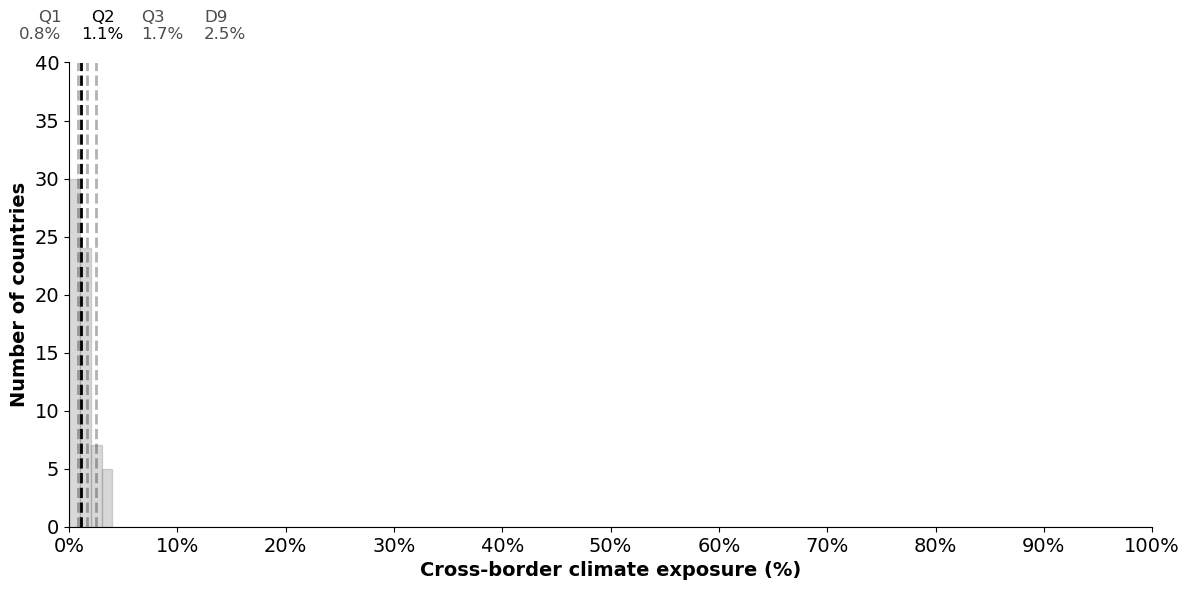

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

# Define a function to count rows in bins
def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

color_palette = sns.color_palette("Set1", 7)

# Define the number of bins and calculate the bin edges
bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

# Count rows for the entire dataset
total_row_counts = count_rows_in_bins(df, bins, 'High Risk Exposure (%)')
data_to_plot = total_row_counts
color = 'grey'

# Width of the bars
bar_width = (bins[1] - bins[0])
bar_positions = bins[:-1] + bar_width / 2

# Create a plot
plt.figure(figsize=(12, 6))
plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center', edgecolor='grey', alpha=0.3)

# Calculate and plot median and quartiles
flat_data = resulting_dataframe_country_inputs_leontief['High Risk Exposure (%)']
median_value = np.median(flat_data)
first_quartile = np.percentile(flat_data, 25)
third_quartile = np.percentile(flat_data, 75)
ninth_decile = np.percentile(flat_data, 90)

plt.axvline(median_value, color='black', linestyle='dashed', linewidth=2)
plt.axvline(first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
plt.axvline(third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
plt.axvline(ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)

# Annotate the lines
plt.text(median_value+2, 42 , f'Q2\n{median_value:.1f}%', horizontalalignment='center', color='black',fontsize=12)
plt.text(first_quartile-1.5, 42, f'Q1\n{first_quartile:.1f}%', horizontalalignment='right', color='black', alpha=0.7,fontsize=12)
plt.text(third_quartile+5, 42, f'Q3\n{third_quartile:.1f}%', horizontalalignment='left', color='black', alpha=0.7,fontsize=12)
plt.text(ninth_decile+10, 42, f'D9\n{ninth_decile:.1f}%', horizontalalignment='left', color='black', alpha=0.7,fontsize=12)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Titles
plt.xlabel('Cross-border climate exposure (%)',fontsize=14,fontweight='bold')
plt.ylabel('Number of countries',fontsize=14,fontweight='bold')

plt.xlim([0, 100])
plt.ylim([0, 40])

plt.tight_layout()

plt.savefig(r"Figures\Supp Mat\B\Fig1d.png")

plt.show()

#### Share of risky trade partners
----

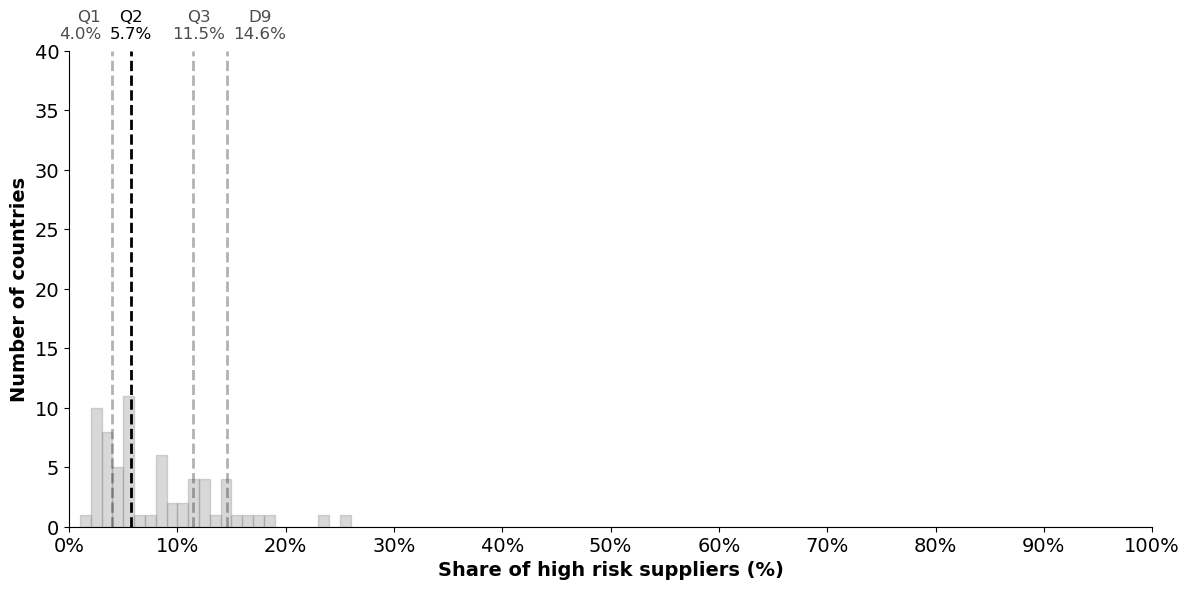

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

color_palette = sns.color_palette("Set1", 7)

def plot_country_distribution(df, graph_type='total', x_max=None, y_max=None):
    """
    Plots the specified type of country distribution graph.

    :param df: DataFrame with the data.
    :param graph_type: Type of graph ('total' or 'risk_comparison').
    :param x_max: Maximum value for the x-axis.
    :param y_max: Maximum value for the y-axis.
    """
    # Define the number of bins and calculate the bin edges
    bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

    if graph_type == 'total':
        # Count rows for the entire dataset
        total_row_counts = count_rows_in_bins(df, bins, 'Share of Risky Trade Partners (%)')
        data_to_plot = total_row_counts
        color = 'grey'
        label = None
    elif graph_type == 'risk_comparison':
        # Separate the data into two groups based on 'Local Risk'
        low_risk_df = df[df['Local Risk'] == 'Low Risk']
        high_risk_df = df[df['Local Risk'] == 'Share of Risky Trade Partners (%)']
        low_risk_row_counts = count_rows_in_bins(low_risk_df, bins, 'Share of Risky Trade Partners (%)')
        high_risk_row_counts = count_rows_in_bins(high_risk_df, bins, 'Share of Risky Trade Partners (%)')
        data_to_plot = [low_risk_row_counts, high_risk_row_counts]
        color = [color_palette[1], color_palette[0]]
        label = ['Low Local Risk', 'High Local Risk']

    # Width of the bars
    bar_width = (bins[1] - bins[0])
    bar_positions = bins[:-1] + bar_width / 2

    # Create a plot
    plt.figure(figsize=(12, 6))

    if graph_type == 'total':
        plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center', edgecolor='grey', alpha=0.3)
    elif graph_type == 'risk_comparison':
        plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='grey')
        plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='grey')
        plt.legend()

    # Calculate and plot median and quartiles if data_to_plot is not None
    flat_data = resulting_dataframe_country_inputs_leontief['Share of Risky Trade Partners (%)']
    median_value = np.median(flat_data)
    first_quartile = np.percentile(flat_data, 25)
    third_quartile = np.percentile(flat_data, 75)
    ninth_decile = np.percentile(flat_data, 90)

    plt.axvline(median_value, color='black', linestyle='dashed', linewidth=2)
    plt.axvline(first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)

    # Annotate the lines
    plt.text(median_value, 41, f'Q2\n{median_value:.1f}%', horizontalalignment='center', color='black',fontsize=12)
    plt.text(first_quartile-1, 41, f'Q1\n{first_quartile:.1f}%', horizontalalignment='right', color='black', alpha=0.7,fontsize=12)
    plt.text(third_quartile+0.5, 41, f'Q3\n{third_quartile:.1f}%', horizontalalignment='center', color='black', alpha=0.7,fontsize=12)
    plt.text(ninth_decile+3, 41, f'D9\n{ninth_decile:.1f}%', horizontalalignment='center', color='black', alpha=0.7,fontsize=12)

    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    # Titles
    plt.xlabel('Share of high risk suppliers (%)',fontsize=14,fontweight='bold')
    plt.ylabel('Number of countries',fontsize=14,fontweight='bold')

    if x_max is not None:
        ax.set_xlim([0, x_max])
    if y_max is not None:
        ax.set_ylim([0, y_max])

    plt.tight_layout()
    plt.savefig(r"Figures\Supp Mat\B\Fig3d.png")

    plt.show()
        
# Usage examples
graph = "total" 
# graph='risk_comparison'
plot_country_distribution(df, graph_type=graph, x_max=100, y_max=40)

## Consumption

In [12]:
import pandas as pd

x = mriot.x
final_production_by_use = mriot.Y.copy()
y = final_production_by_use.sum(axis = 1)

L = mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()

multi_index = pd.MultiIndex.from_product([country_list, country_list, sector_list], names=['No risk country', 'Country', 'Sector'])

values = {'Low Risk': [0] * multi_index.size}
risk_cs_low = pd.DataFrame(values, index=multi_index)

values = {'High Risk': [0] * multi_index.size}
risk_cs_high = pd.DataFrame(values, index=multi_index)

values = {'ROW': [0] * multi_index.size}
risk_cs_row = pd.DataFrame(values, index=multi_index)

def indicator(element, lst):
    return 1 if element in lst else 0

for cc in country_list:   
    country_list_except = [x for x in country_list if x != cc]
    for c in country_list_except:
        for s in sector_list:
            low_risk_countries_except =  [x for x in low_risk_countries if x != cc] ## cc is not risky, but c is, if it is in high_risk_countries
            high_risk_countries_except =  [x for x in high_risk_countries if x != cc]

            risk_cs_low.loc[cc,c,s] = y.loc[c,s]*indicator(c,low_risk_countries)+y.loc[c,s]*L[c,s].loc[low_risk_countries_except].sum()
            risk_cs_high.loc[cc,c,s] = y.loc[c,s]*indicator(c,high_risk_countries)+y.loc[c,s]*L[c,s].loc[high_risk_countries_except].sum()
            risk_cs_row.loc[cc,c,s] = y.loc[c,s]*indicator(c,['ROW'])+y.loc[c,s]*L[c,s].loc[['ROW']].sum()
            
            total = y.loc[c,s]+y.loc[c,s]*L[c,s].sum()
            
            risk_cs_low.loc[cc,c,s] = risk_cs_low.loc[cc,c,s]/total*100
            risk_cs_high.loc[cc,c,s] = risk_cs_high.loc[cc,c,s]/total*100
            risk_cs_row.loc[cc,c,s] = risk_cs_row.loc[cc,c,s]/total*100

    # List of DataFrames to concatenate
    risk_cs = [risk_cs_low, risk_cs_high,risk_cs_row]

    # Concatenate the DataFrames along columns (axis=1)
    risk_cs = pd.concat(risk_cs,axis=1)
    
# Replace all NaN values with zeros
risk_cs = risk_cs.fillna(0)

C:\Users\delah\AppData\Local\Temp\ipykernel_14980\1341594425.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '60012.05237815306' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  risk_cs_low.loc[cc,c,s] = y.loc[c,s]*indicator(c,low_risk_countries)+y.loc[c,s]*L[c,s].loc[low_risk_countries_except].sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_14980\1341594425.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '439.23263415404915' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  risk_cs_high.loc[cc,c,s] = y.loc[c,s]*indicator(c,high_risk_countries)+y.loc[c,s]*L[c,s].loc[high_risk_countries_except].sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_14980\1341594425.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a futur

In [14]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/risk_cs_consumption_leontief_icio.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(risk_cs, f)

In [15]:
import pickle
import pandas as pd


# Explicit file path
file_path_pickle = 'ND_GAIN/results/risk_cs_consumption_leontief_icio.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    risk_cs = pickle.load(f)

In [16]:
import pandas as pd

final_production_by_use = mriot.Y.copy()
y = final_production_by_use.sum(axis = 1) # final production of (c,s), whatever use

Y = final_production_by_use.T.groupby('region').sum().T

x = mriot.x # Gross output

L= mriot.L # Leontief matrix

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()


values = {'Low Risk': [0] * country_list.size}
cConsoFin_low = pd.DataFrame(values, index=country_list)

values = {'High Risk': [0] * country_list.size}
cConsoFin_high = pd.DataFrame(values, index=country_list)

values = {'ROW': [0] * country_list.size}
cConsoFin_row = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cConsoFin_Foreign = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cConsoFin_Local = pd.DataFrame(values, index=country_list)

for cc in country_list:
    Y_cc = Y[cc]
    Y_cc_tot = Y_cc.sum()
    country_list_except = [x for x in country_list if x != cc]

    for c in country_list_except:
        for s in sector_list:
            cConsoFin_low.loc[cc] = cConsoFin_low.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['Low Risk']/100
            cConsoFin_high.loc[cc] = cConsoFin_high.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['High Risk']/100
            cConsoFin_row.loc[cc] = cConsoFin_row.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['ROW']/100

    cConsoFin_Foreign.loc[cc] = cConsoFin_low.loc[cc].iloc[0] + cConsoFin_high.loc[cc].iloc[0] + cConsoFin_row.loc[cc].iloc[0]
    cConsoFin_Local.loc[cc] = Y_cc_tot - cConsoFin_Foreign.loc[cc].iloc[0]

    #Ratios
    cConsoFin_low.loc[cc]=cConsoFin_low.loc[cc].iloc[0]/Y_cc_tot*100
    cConsoFin_high.loc[cc]=cConsoFin_high.loc[cc].iloc[0]/Y_cc_tot*100
    cConsoFin_row.loc[cc]=cConsoFin_row.loc[cc].iloc[0]/Y_cc_tot*100

    cConsoFin_Local.loc[cc]=cConsoFin_Local.loc[cc].iloc[0]/Y_cc_tot*100
    cConsoFin_Foreign.loc[cc]=cConsoFin_Foreign.loc[cc].iloc[0]/Y_cc_tot*100
    
# List of DataFrames to concatenate
dataframes_to_concat = [cConsoFin_low, cConsoFin_high,cConsoFin_row, cConsoFin_Foreign, cConsoFin_Local]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_cons_leontief = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_cons_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

result=result[result['Local Risk']!='Unknown']

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

resulting_dataframe_country_cons_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_14980\2294203032.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.92410114649138' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cConsoFin_low.loc[cc] = cConsoFin_low.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['Low Risk']/100
C:\Users\delah\AppData\Local\Temp\ipykernel_14980\2294203032.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.006763564396040367' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cConsoFin_high.loc[cc] = cConsoFin_high.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['High Risk']/100
C:\Users\delah\AppData\Local\Temp\ipykernel_14980\2294203032.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.00621500111

In [17]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_country_cons_leontief_icio.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_country_cons_leontief, f)

In [10]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_country_cons_leontief_icio.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_cons_leontief= pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'ND_GAIN/results/resulting_dataframe_country_cons_leontief_icio.pkl'

In [18]:
df=resulting_dataframe_country_cons_leontief
median_high_risk_developed_consumption = df[df['Development'] == 'Developed']['High Risk Exposure (%)'].median()

median_high_risk_developed_consumption

0.7884299177375732

# Sector-level analysis

## Inputs

In [20]:
import pandas as pd    

Y = mriot.Y.copy()
x = mriot.x
y = Y.sum(axis = 1)

L= mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()

index_cs = mriot.x.index

values = {'Low Risk': [0] * index_cs.size}
Foreign_Inputs_low = pd.DataFrame(values, index=index_cs)

values = {'High Risk': [0] * index_cs.size}
Foreign_Inputs_high = pd.DataFrame(values, index=index_cs)

values = {'ROW': [0] * index_cs.size}
Foreign_Inputs_ROW = pd.DataFrame(values, index=index_cs)

values = {'Local (%)': [0] * index_cs.size}
Local_Inputs = pd.DataFrame(values, index=index_cs)

values = {'Foreign (%)': [0] * index_cs.size}
Foreign_Inputs = pd.DataFrame(values, index=index_cs)


for s in sector_list:    
    for c in country_list:
        L_c = L[c]
        y_c = y[c]
        
        inputs_cs = L_c.groupby('sector').sum().loc[s].dot(y_c)  # products s used as inputs for all sectors of c's economy
        
        if inputs_cs != 0 :
            Foreign_Inputs.loc[c,s]= L_c.loc[L_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
            Local_Inputs.loc[c,s] = L_c.loc[~L_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
            Foreign_Inputs_low.loc[c,s] =  L_c.loc[~L_c.index.get_level_values('region').isin([c]) & L_c.index.get_level_values('region').isin(low_risk_countries)].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
            Foreign_Inputs_high.loc[c,s] = L_c.loc[~L_c.index.get_level_values('region').isin([c]) & L_c.index.get_level_values('region').isin(high_risk_countries)].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
            #Foreign_Inputs_ROW.loc[c,s] = L_c.loc[~L_c.index.get_level_values('region').isin([c]) & L_c.index.get_level_values('region').isin(['ROW'])].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100

# List of DataFrames to concatenate
dataframes_to_concat = [Foreign_Inputs_low, Foreign_Inputs_high, Foreign_Inputs_ROW,Foreign_Inputs, Local_Inputs]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_sectors_inputs_leontief = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_sectors_inputs_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

result=result[result['Local Risk']!='Unknown']

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development','sector', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

resulting_dataframe_sectors_inputs_leontief=result

C:\Users\delah\AppData\Local\Temp\ipykernel_14980\2907869453.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '95.78711088151195' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Foreign_Inputs.loc[c,s]= L_c.loc[L_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
C:\Users\delah\AppData\Local\Temp\ipykernel_14980\2907869453.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '4.212889118488039' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Local_Inputs.loc[c,s] = L_c.loc[~L_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
C:\Users\delah\AppData\Local\Temp\ipykernel_14980\2907869453.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and wil

## Consumption

In [31]:
import pickle
import pandas as pd


# Explicit file path
file_path_pickle = 'ND_GAIN/results/risk_cs_consumption_leontief_icio.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    risk_cs = pickle.load(f)

In [32]:
index_cs = L.index

L = mriot.L

Y = mriot.Y.copy()
idx = pd.IndexSlice
# List of categories you want to keep
# List of categories you want to keep
categories_to_keep = [
    'HFCE'
]

# Filtering to get only columns where the second level matches the categories listed
Y = Y.loc[:, idx[:, categories_to_keep]]

final_production_by_destination_cons = Y.groupby(level='region', axis=1).sum()

ConsoFin = final_production_by_destination_cons[c]
ConsoFin_tot=ConsoFin.groupby('sector').sum()

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()


values = {'Low Risk': [0] * index_cs.size}
ConsoFin_Low = pd.DataFrame(values, index=index_cs)

values = {'High Risk': [0] * index_cs.size}
ConsoFin_High = pd.DataFrame(values, index=index_cs)

values = {'ROW': [0] * index_cs.size}
ConsoFin_row = pd.DataFrame(values, index=index_cs)

values = {'Foreign (%)': [0] * index_cs.size}
ConsoFin_Foreign = pd.DataFrame(values, index=index_cs)

values = {'Local (%)': [0] * index_cs.size}
ConsoFin_Local = pd.DataFrame(values, index=index_cs)

for c in country_list:
    ConsoFin = final_production_by_destination_cons[c]
    ConsoFin_tot=ConsoFin.groupby('sector').sum()
    country_list_except = [x for x in country_list if x != c]
    for s in sector_list:
        if ConsoFin_tot.loc[s]>0:
            for cc in country_list:
                ConsoFin_Low.loc[c,s] = ConsoFin_Low.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[c].loc[(cc, s), 'Low Risk']/100
                ConsoFin_High.loc[c,s] = ConsoFin_High.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[c].loc[(cc, s), 'High Risk']/100
                ConsoFin_row.loc[c,s] = ConsoFin_row.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[c].loc[(cc, s), 'ROW']/100

            ConsoFin_Low.loc[c,s] = ConsoFin_Low.loc[c,s] / ConsoFin_tot.loc[s]*100
            ConsoFin_High.loc[c,s] = ConsoFin_High.loc[c,s] / ConsoFin_tot.loc[s]*100
            ConsoFin_row.loc[c,s] = ConsoFin_row.loc[c,s] / ConsoFin_tot.loc[s]*100

            ConsoFin_Foreign.loc[c,s] = ConsoFin_Low.loc[c,s].iloc[0] + ConsoFin_High.loc[c,s].iloc[0]+ConsoFin_row.loc[c,s].iloc[0]
            ConsoFin_Local.loc[c,s] = 100 - ConsoFin_Foreign.loc[c,s].iloc[0]
            
# List of DataFrames to concatenate
dataframes_to_concat = [ConsoFin_Low, ConsoFin_High, ConsoFin_row, ConsoFin_Foreign, ConsoFin_Local]

resulting_dataframe_sectors_cons_leontief = pd.concat(dataframes_to_concat, axis=1)

result = resulting_dataframe_sectors_cons_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

result=result[result['Local Risk']!='Unknown']

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development','sector', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

resulting_dataframe_sectors_cons_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_14980\1718851344.py:18: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  final_production_by_destination_cons = Y.groupby(level='region', axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_14980\1718851344.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.903220390240799' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ConsoFin_Low.loc[c,s] = ConsoFin_Low.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[c].loc[(cc, s), 'Low Risk']/100
C:\Users\delah\AppData\Local\Temp\ipykernel_14980\1718851344.py:50: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.006610736602161915' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ConsoFin_High.loc[c,s] = ConsoFin_High.loc[

In [35]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_sectors_cons_leontief_icio_ndgain.pkl'

# Save the dictionary to a file
with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_sectors_cons_leontief, f)

In [36]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_sectors_cons_leontief_icio_ndgain.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_sectors_cons_leontief = pickle.load(f)

## Concentration

### Code

Inputs

In [23]:
multi_index = pd.MultiIndex.from_product([country_list, sector_list], names=['country', 'sector'])

values = {'HHI': [0] * multi_index.size}
hhi_inputs = pd.DataFrame(values, index=multi_index)

L=mriot.L
y= Y.sum(axis = 1)

for c in country_list:
    for s in sector_list:
        L_c=L[c]
        y_c=y[c]
        L_c=L_c.loc[~L.index.get_level_values('region').isin([c])]
        total_inputs_ext_s_to_c = L_c.groupby('sector').sum().loc[s].dot(y_c)
        hhi=0
        if total_inputs_ext_s_to_c>0:
            hhi=0
            country_list_except_c = [item for item in country_list if item != c]
            for c0 in country_list_except_c:
                share_c0 = L_c.loc[c0,s].dot(y_c)/total_inputs_ext_s_to_c
                hhi = hhi + share_c0**2
        hhi_inputs.loc[c,s]=hhi

C:\Users\delah\AppData\Local\Temp\ipykernel_14980\41654026.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.23213742441131155' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  hhi_inputs.loc[c,s]=hhi


Consumption

In [25]:
multi_index = pd.MultiIndex.from_product([country_list, sector_list], names=['country', 'sector'])

values = {'HHI': [0] * multi_index.size}
hhi_cons = pd.DataFrame(values, index=multi_index)

L=mriot.L
y= Y.sum(axis = 1)

Y = mriot.Y.copy()
idx = pd.IndexSlice
# List of categories you want to keep
categories_to_keep = [
    'HFCE',
    'NPISH',
    'GGFC','DPABR'
]


# Filtering to get only columns where the second level matches the categories listed
Y = Y.loc[:, idx[:, categories_to_keep]]

Y = Y.groupby(level='region', axis=1).sum()

for c in country_list:
    for s in sector_list:
        Y_c =Y[c]
        total_cons_ext_s_to_c = Y_c.loc[~Y_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s]
        hhi=0
        if total_cons_ext_s_to_c>0:
            country_list_except_c = [item for item in country_list if item != c]
            for c0 in country_list_except_c:
                share_c0 = Y_c.loc[c0,s]/total_cons_ext_s_to_c
                hhi = hhi + share_c0**2
        hhi_cons.loc[c,s]=hhi

C:\Users\delah\AppData\Local\Temp\ipykernel_14980\4257885057.py:22: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  Y = Y.groupby(level='region', axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_14980\4257885057.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.33323142814842976' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  hhi_cons.loc[c,s]=hhi


### Plot

In [37]:
df1=resulting_dataframe_sectors_cons_leontief
df2=hhi_cons
result = pd.merge(df1, df2, left_on=['Country Code', 'sector'], right_on=['country', 'sector'], how='left')
df=result

In [27]:
df1=resulting_dataframe_sectors_inputs_leontief_2
df2=hhi_inputs
result = pd.merge(df1, df2, left_on=['Country Code', 'sector'], right_on=['country', 'sector'], how='left')
df=result

C:\Users\delah\AppData\Local\Temp\ipykernel_14980\1289871464.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (filtered_sector_medians['High Risk Exposure (%)'][i], filtered_sector_medians['HHI'][i]),fontsize=13)


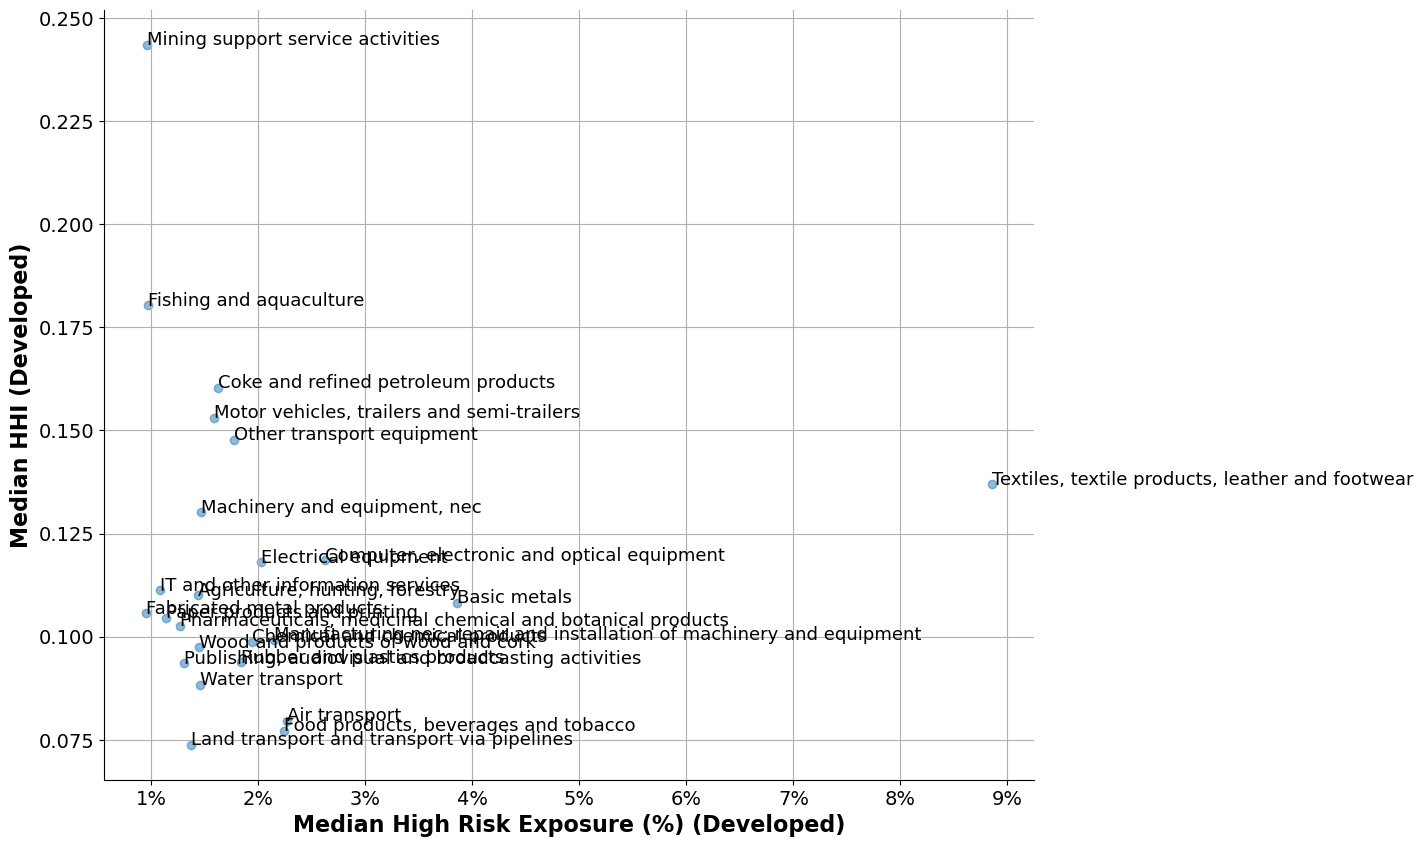

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your data is already in a DataFrame named 'df'
# Filter the DataFrame to only include rows where Development is 'Developed'
developed_df = df[df['Development'] == 'Developed']

# Group by 'sector' and calculate median values specifically for numeric columns
sector_medians = developed_df.groupby('sector').median(numeric_only=True)[['High Risk Exposure (%)', 'HHI']]

# Filter out sectors where the median High Risk Exposure (%) is less than 2%
#filtered_sector_medians = sector_medians[sector_medians['High Risk Exposure (%)'] >= median_high_risk_developed_consumption]
filtered_sector_medians = sector_medians[sector_medians['High Risk Exposure (%)'] >= median_high_risk_developed_inputs]

# Plotting
plt.figure(figsize=(12, 10))
ax = plt.gca()  # Get current axis

# Removing top and right borders and setting the bottom and left spines black
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# Scatter plot without the incorrect 'fontsize' parameter
plt.scatter(filtered_sector_medians['High Risk Exposure (%)'], filtered_sector_medians['HHI'], alpha=0.5)

# Setting labels with font size and weight adjustments
plt.xlabel('Median High Risk Exposure (%) (Developed)', fontsize=16, fontweight='bold')
plt.ylabel('Median HHI (Developed)', fontsize=16, fontweight='bold')

# Formatting the x-axis labels as percentages and setting label sizes
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# Setting grid
plt.grid(True)

# Adding sector labels to the points
for i, txt in enumerate(filtered_sector_medians.index):
    plt.annotate(txt, (filtered_sector_medians['High Risk Exposure (%)'][i], filtered_sector_medians['HHI'][i]),fontsize=13)

plt.show()